# P&B scale-free impact workbench

This is the canonical workbench for the selected impact model. Its active model is
the activity-adjusted P&B surface, `pb_activity`. Rejected extensions are retained
in their result directories and in Git history, but their detailed diagnostics no
longer obscure the working model.

The notebook keeps three questions separate:

1. Does one contemporaneous impact law work across event scales?
2. Is its calibration stable through calendar time?
3. Do current and lagged residuals predict returns after the bar has closed?

June--August 2026 remain untouched holdout months.

## Selected impact model

For a completed event bar,

$$
z_t=\frac{|Q_t|}{V_t},\qquad
a_t=\frac{V_t}{V_{24h,t}},\qquad
y_t=\frac{s_t r_t}{\sigma_{24h,t}},
$$

where $s_t=\operatorname{sign}(Q_t)$. Event-count scaling is

$$
\mathcal Q_N=\mathcal Q_{1000}\left(\frac{N}{1000}\right)^\xi,
\qquad
\mathcal R_{N,s}=\mathcal R_{1000,s}
\left(\frac{N}{1000}\right)^\psi.
$$

The selected pressure coordinate and response are

$$
u_t=\frac{z_ta_t^\gamma}{\mathcal Q_N},
\qquad
\widehat y_t=\mathcal R_{N,s_t}
\frac{u_t}{(1+u_t^\alpha)^{\beta/\alpha}}.
$$

Buy and sell bars share the shape and scaling exponents but retain separate
response levels. The contemporaneous residual is

$$
\varepsilon_t=y_t-\widehat y_t.
$$

The fit uses completed-bar information and is an explanatory impact benchmark,
not a trade available at the beginning of the same bar.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')

CANONICAL_RESULTS = REPO / 'alpha-search' / 'reports' / 'pb_surface_scaling_v1'
CANONICAL_CONFIG = REPO / 'alpha-search' / 'configs' / 'pb_surface_scaling_v1.json'
config = json.loads(CANONICAL_CONFIG.read_text())
fits = pl.read_csv(CANONICAL_RESULTS / 'scaling_fits.csv', infer_schema_length=None)
evaluation = pl.read_csv(
    CANONICAL_RESULTS / 'scaling_evaluation.csv', infer_schema_length=None
)
collapsed = pl.read_csv(
    CANONICAL_RESULTS / 'collapsed_cells.csv', infer_schema_length=None
)
evolution = pl.read_csv(CANONICAL_RESULTS / 'market_evolution.csv')

SELECTION_RESULTS = REPO / 'alpha-search' / 'reports' / 'pb_activity_beta_extension_v3'
selection_evaluation = pl.read_csv(
    SELECTION_RESULTS / 'scaling_evaluation.csv', infer_schema_length=None
)

ACTIVITY_RESULTS = REPO / 'alpha-search' / 'reports' / 'pb_residual_activity_diagnostics_v1'
monthly_activity = pl.read_csv(
    ACTIVITY_RESULTS / 'monthly_activity_relations.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))

LAG_RESULTS = REPO / 'alpha-search' / 'reports' / 'pb_lagged_impact_extension_v4'
lag_config = json.loads(
    (REPO / 'alpha-search' / 'configs' / 'pb_lagged_impact_extension_v4.json').read_text()
)
lag_evaluation = pl.read_csv(
    LAG_RESULTS / 'oos_evaluation.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
lag_coefficients = pl.read_csv(
    LAG_RESULTS / 'lag_coefficients.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
lag_curves = pl.read_csv(
    LAG_RESULTS / 'lag_diagnostic_curves.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))
calibration_ledger = pl.read_csv(
    LAG_RESULTS / 'calibration_ledger.csv', infer_schema_length=None
).with_columns(pl.col('fold').cast(pl.Utf8))

ROLLING_RESULTS = REPO / 'alpha-search' / 'reports' / 'rolling_pb_residual_response_v2'
rolling_config = json.loads(
    (REPO / 'alpha-search' / 'configs' / 'rolling_pb_residual_response_v2.json').read_text()
)
residual_ic_summary = pl.read_csv(ROLLING_RESULTS / 'residual_ic_summary.csv')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def horizon_label(seconds):
    seconds = int(seconds)
    return f'{seconds}s' if seconds < 60 else f'{seconds/60:g}m'

## Manual controls

In [2]:
SAMPLE = 'full_history'           # full_history or post_2021
OOS_FOLD = '3'                    # 1=2023, 2=2024, 3=2025, 4=Jan-May 2026
DISPLAY_SCALES = [200, 500, 1000, 2000, 4000, 8000]
DIAGNOSTIC_EVENT_SIZE = 1000

LAG_MODEL = 'lag_impact'          # preferred; activity variants remain sensitivities

IC_TRAINING_WINDOW = 12           # 6 or 12 months
IC_HORIZON_SECONDS = 15 * 60      # 30s, 1m, 2m, 5m, 10m, 15m, 30m, or 60m
IC_SIDE = 'all'                   # all, buy, or sell
RESIDUAL_VARIANT = 'conditional_z' # conditional_z or scaled

assert SAMPLE in {'full_history', 'post_2021'}
assert OOS_FOLD in {'1', '2', '3', '4'}
assert DIAGNOSTIC_EVENT_SIZE in DISPLAY_SCALES
assert LAG_MODEL in {'lag_impact', 'lag_activity', 'lag_activity_duration'}
assert IC_TRAINING_WINDOW in {6, 12}
assert IC_HORIZON_SECONDS in set(rolling_config['future_horizons_seconds'])
assert IC_SIDE in {'all', 'buy', 'sell'}
assert RESIDUAL_VARIANT in {'conditional_z', 'scaled'}

fold_definition = next(
    row for row in config['folds'] if str(row['fold']) == OOS_FOLD
)
display(Markdown(
    f"**Selected view:** `{SAMPLE}` using the canonical `pb_activity` model. "
    f"Fold {OOS_FOLD} is trained strictly before "
    f"`{fold_definition['train_end']}` and tested from "
    f"`{fold_definition['test_start']}` to `{fold_definition['test_end']}`."
))

**Selected view:** `full_history` using the canonical `pb_activity` model. Fold 3 is trained strictly before `2025-01-01` and tested from `2025-01-01` to `2026-01-01`.

## Model-selection record

Only `pb_activity` is active. The table remains as a compact audit trail; rejected
models are not used in subsequent charts or residual construction.

In [3]:
DECISIONS = {
    'pb_classic': 'benchmark: activity exponent fixed at 1',
    'pb_activity': 'selected model',
    'pb_activity_vertical': 'rejected: negligible gain, weak identification',
    'pb_activity_beta': 'rejected: negligible gain, unstable parameters',
    'pb_activity_generalised': 'rejected: extra central exponent not earned',
    'independent_power_surface': 'flexible benchmark only',
}
selection = (
    selection_evaluation.filter(
        (pl.col('split') == 'test') &
        (pl.col('n_events') == 'all') &
        (pl.col('side') == 'all')
    )
    .group_by('sample', 'family')
    .agg(
        pl.col('cell_rmse').mean().alias('mean_oos_cell_rmse'),
        pl.col('cell_rmse').max().alias('worst_oos_cell_rmse'),
        pl.col('residual_log_activity_correlation').mean()
        .alias('mean_residual_activity_correlation'),
    )
    .with_columns(pl.col('family').replace(DECISIONS).alias('decision'))
    .sort(['sample', 'mean_oos_cell_rmse'])
)
display(selection)

sample,family,mean_oos_cell_rmse,worst_oos_cell_rmse,mean_residual_activity_correlation,decision
str,str,f64,f64,f64,str
"""full_history""","""independent_power_surface""",0.004299,0.005752,-0.455571,"""flexible benchmark only"""
"""full_history""","""pb_activity_vertical""",0.004303,0.005655,-0.496274,"""rejected: negligible gain, wea…"
"""full_history""","""pb_activity_beta""",0.004329,0.005673,-0.501239,"""rejected: negligible gain, uns…"
"""full_history""","""pb_activity""",0.004342,0.005689,-0.49886,"""selected model"""
"""full_history""","""pb_activity_generalised""",0.004343,0.00569,-0.496471,"""rejected: extra central expone…"
…,…,…,…,…,…
"""post_2021""","""pb_activity_vertical""",0.003968,0.005273,-0.460344,"""rejected: negligible gain, wea…"
"""post_2021""","""pb_activity_beta""",0.00397,0.005251,-0.42508,"""rejected: negligible gain, uns…"
"""post_2021""","""pb_activity""",0.004035,0.005357,-0.453458,"""selected model"""


## How the event clock changed

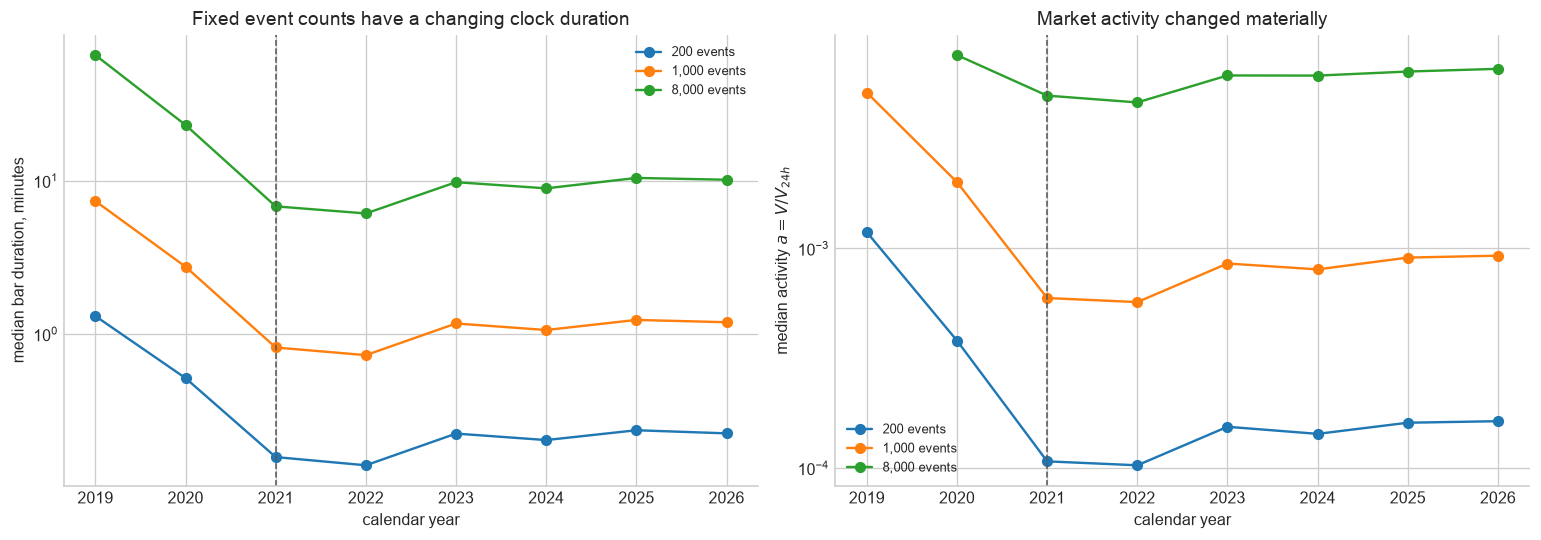

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for n_events in [200, 1000, 8000]:
    part = evolution.filter(pl.col('n_events') == n_events).sort('year')
    axes[0].plot(
        part['year'], part['median_duration_seconds'] / 60,
        'o-', label=f'{n_events:,} events'
    )
    axes[1].plot(
        part['year'], part['median_relative_activity'],
        'o-', label=f'{n_events:,} events'
    )
axes[0].set_yscale('log')
axes[0].set_ylabel('median bar duration, minutes')
axes[0].set_title('Fixed event counts have a changing clock duration')
axes[1].set_yscale('log')
axes[1].set_ylabel(r'median activity $a=V/V_{24h}$')
axes[1].set_title('Market activity changed materially')
for ax in axes:
    ax.axvline(2021, color='0.35', ls='--', lw=1)
    ax.set_xlabel('calendar year')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Selected model: full-fit parameters and collapse

sample,q_reference,q_exponent_xi,r_buy_reference,r_sell_reference,r_exponent_psi,activity_exponent_gamma,shape_alpha,shape_beta,tail_exponent,cell_rmse
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""full_history""",0.002856,0.413219,0.015906,0.015271,0.632451,0.588704,1.623069,0.277225,0.722775,0.001367
"""post_2021""",0.003268,0.392122,0.013664,0.013116,0.651589,0.55349,1.893039,0.244797,0.755203,0.001528


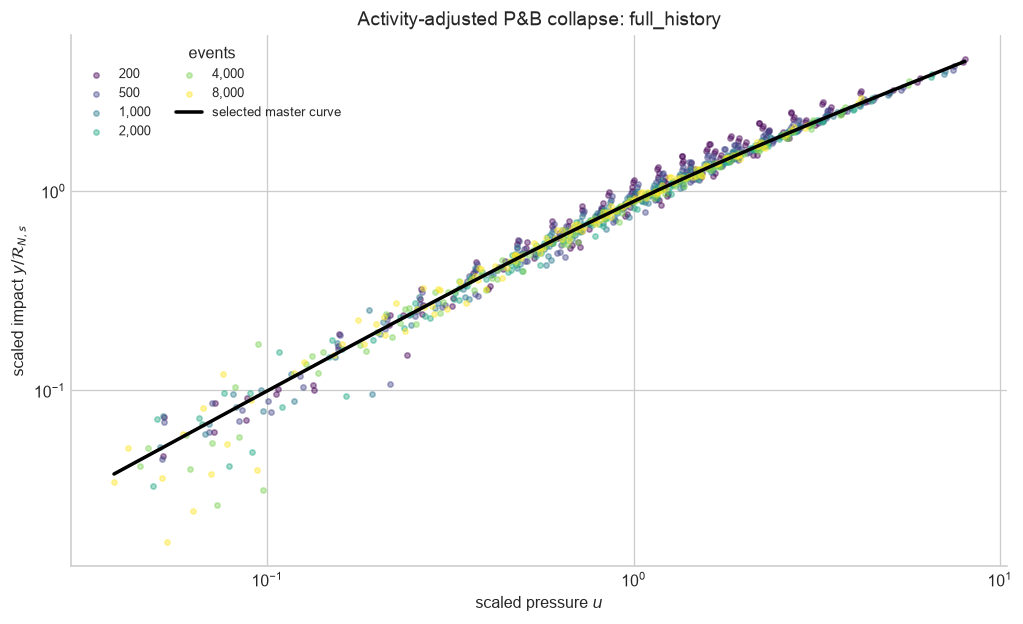

In [5]:
parameter_columns = [
    'sample', 'q_reference', 'q_exponent_xi',
    'r_buy_reference', 'r_sell_reference', 'r_exponent_psi',
    'activity_exponent_gamma', 'shape_alpha', 'shape_beta',
    'tail_exponent', 'cell_rmse'
]
display(
    fits.filter(
        (pl.col('fold') == 'full_fit') &
        (pl.col('family') == 'pb_activity')
    ).select(parameter_columns).sort('sample')
)

view = collapsed.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('family') == 'pb_activity') &
    pl.col('n_events').is_in(DISPLAY_SCALES) &
    (pl.col('scaled_observed_impact') > 0)
)
fit = fits.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') == 'full_fit') &
    (pl.col('family') == 'pb_activity')
).row(0, named=True)

fig, ax = plt.subplots(figsize=(10.5, 6.0))
cmap = plt.get_cmap('viridis')
for index, n_events in enumerate(DISPLAY_SCALES):
    part = view.filter(pl.col('n_events') == n_events)
    ax.scatter(
        part['scaled_pressure'], part['scaled_observed_impact'],
        s=11, alpha=.42,
        color=cmap(index / max(1, len(DISPLAY_SCALES)-1)),
        label=f'{n_events:,}'
    )
grid = np.geomspace(view['scaled_pressure'].min(), view['scaled_pressure'].max(), 500)
curve = grid / (1 + grid ** fit['shape_alpha']) ** (
    fit['shape_beta'] / fit['shape_alpha']
)
ax.plot(grid, curve, color='black', lw=2.2, label='selected master curve')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'scaled pressure $u$')
ax.set_ylabel(r'scaled impact $y/\mathcal{R}_{N,s}$')
ax.set_title(f'Activity-adjusted P&B collapse: {SAMPLE}')
ax.legend(title='events', fontsize=8, ncol=2)
plt.show()

## Chronological performance and parameter drift

n_events_numeric,mean_oos_cell_rmse,worst_oos_cell_rmse
i64,f64,f64
200,0.001887,0.002498
500,0.002325,0.002761
1000,0.002824,0.003519
2000,0.003746,0.005035
4000,0.005268,0.007163
8000,0.007321,0.010225


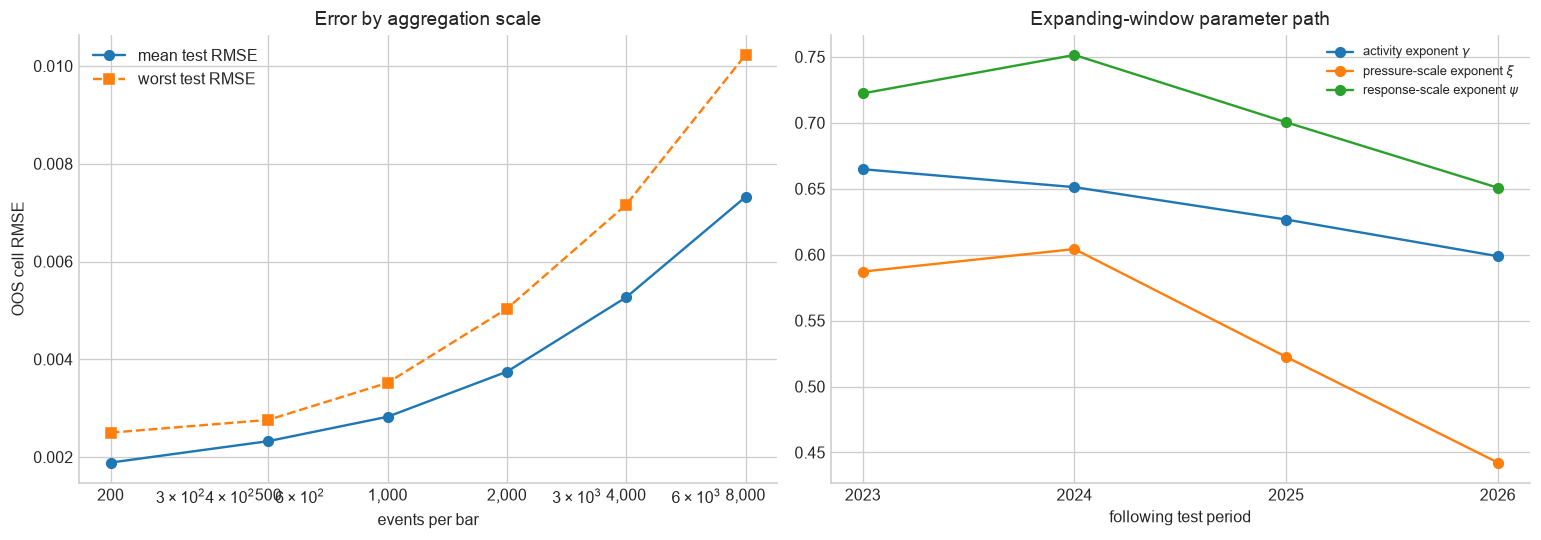

In [6]:
canonical_oos = evaluation.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('family') == 'pb_activity') &
    (pl.col('split') == 'test') &
    (pl.col('side') == 'all') &
    (pl.col('n_events') != 'all')
).with_columns(
    pl.col('n_events').cast(pl.Int64).alias('n_events_numeric'),
    pl.col('fold').cast(pl.Int64).alias('fold_number'),
)
scale_summary = canonical_oos.group_by('n_events_numeric').agg(
    pl.col('cell_rmse').mean().alias('mean_oos_cell_rmse'),
    pl.col('cell_rmse').max().alias('worst_oos_cell_rmse'),
).sort('n_events_numeric')
display(scale_summary)

parameter_path = fits.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('family') == 'pb_activity') &
    (pl.col('fold') != 'full_fit')
).with_columns(pl.col('fold').cast(pl.Int64).alias('fold_number')).sort('fold_number')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].plot(
    scale_summary['n_events_numeric'], scale_summary['mean_oos_cell_rmse'],
    'o-', label='mean test RMSE'
)
axes[0].plot(
    scale_summary['n_events_numeric'], scale_summary['worst_oos_cell_rmse'],
    's--', label='worst test RMSE'
)
axes[0].set_xscale('log')
axes[0].set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
axes[0].set_xlabel('events per bar')
axes[0].set_ylabel('OOS cell RMSE')
axes[0].set_title('Error by aggregation scale')
axes[0].legend()

axes[1].plot(
    parameter_path['fold_number'], parameter_path['activity_exponent_gamma'],
    'o-', label=r'activity exponent $\gamma$'
)
axes[1].plot(
    parameter_path['fold_number'], parameter_path['q_exponent_xi'],
    'o-', label=r'pressure-scale exponent $\xi$'
)
axes[1].plot(
    parameter_path['fold_number'], parameter_path['r_exponent_psi'],
    'o-', label=r'response-scale exponent $\psi$'
)
axes[1].set_xticks([1, 2, 3, 4], ['2023', '2024', '2025', '2026'])
axes[1].set_xlabel('following test period')
axes[1].set_title('Expanding-window parameter path')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Remaining contemporaneous activity structure

The selected static model is useful but not perfect. These correlations are
calculated month by month out of period after removing scaled-pressure-bin means.
They quantify the remaining activity structure without promoting a rejected
nonlinear extension.

n_events,mean_pressure_controlled_correlation,median_pressure_controlled_correlation,months
i64,f64,f64,u32
200,-0.109745,-0.129067,41
500,-0.100963,-0.113578,41
1000,-0.083393,-0.096034,41
2000,-0.05839,-0.069487,41
4000,-0.032165,-0.037731,41
8000,-0.010565,-0.012292,41


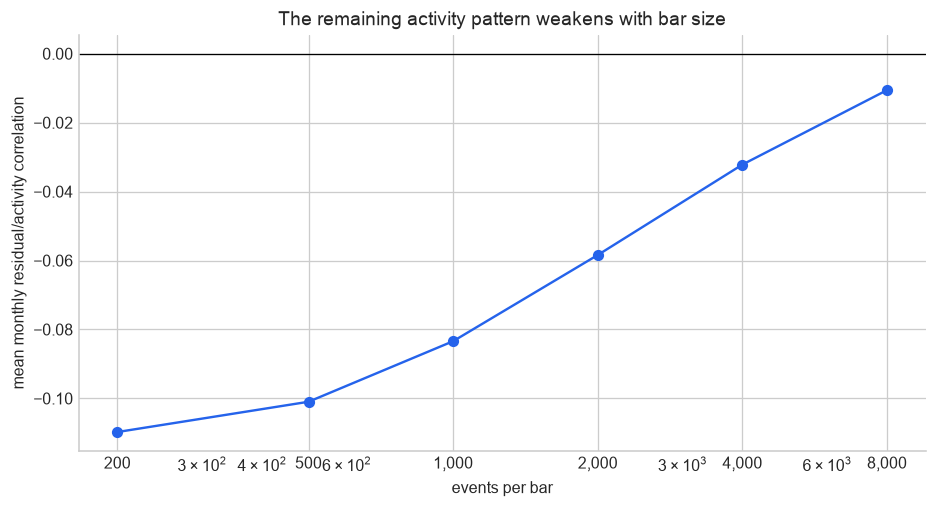

In [7]:
activity_view = monthly_activity.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('side') == 'all')
)
activity_summary = activity_view.group_by('n_events').agg(
    pl.col('pressure_controlled_scaled_correlation').mean()
    .alias('mean_pressure_controlled_correlation'),
    pl.col('pressure_controlled_scaled_correlation').median()
    .alias('median_pressure_controlled_correlation'),
    pl.len().alias('months'),
).sort('n_events')
display(activity_summary)

fig, ax = plt.subplots(figsize=(9.5, 4.7))
ax.plot(
    activity_summary['n_events'],
    activity_summary['mean_pressure_controlled_correlation'],
    'o-', color='#2563eb'
)
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('log')
ax.set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
ax.set_xlabel('events per bar')
ax.set_ylabel('mean monthly residual/activity correlation')
ax.set_title('The remaining activity pattern weakens with bar size')
plt.show()

## Previous-bar reaction: a separate dynamic model

This does not replace the contemporaneous P&B surface. It asks whether impact
from the preceding bar continues or reacts during the current bar.

Let $A_t$ denote the frozen P&B prediction. Define

$$
H_{t-1}=s_ts_{t-1}A_{t-1}.
$$

The diagnostic dynamic equation is

$$
y_t=A_t+c_{s_t}+\kappa H_{t-1}+\eta_t.
$$

For every fold, the P&B parameters are calibrated first and then frozen. Only
$c_{buy}$, $c_{sell}$ and $\kappa$ are subsequently fitted to the training-period
residuals, with equal total weight per training month. Those coefficients are
then frozen for the entire test interval. A negative $\kappa$ means
counterreaction; a positive value means continuation.

This equation is an academic reaction/propagator model. Its lag term is also a
potential ex-ante factor, but the full equation is not a trading rule because
$A_t$ and $s_t$ are not known until the current bar has completed.

In [8]:
selected_ledger = calibration_ledger.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') == OOS_FOLD) &
    (pl.col('n_events') == DIAGNOSTIC_EVENT_SIZE)
).select(
    'sample', 'fold', 'n_events', 'pb_family', 'train_start',
    'pb_calibration_end', 'lag_calibration_end', 'test_start', 'test_end',
    'pb_parameters_frozen_before_lag_fit', 'pb_fit_target', 'lag_fit_target',
    'lag_weighting', 'training_observations', 'test_observations',
    'duration_reference_seconds'
)
display(selected_ledger)

ledger_row = selected_ledger.row(0, named=True)
display(Markdown(
    f"**Selected fold:** P&B and lag calibration use data ending before "
    f"`{ledger_row['pb_calibration_end']}`. Both layers are frozen before the "
    f"test from `{ledger_row['test_start']}` to `{ledger_row['test_end']}`."
))

sample,fold,n_events,pb_family,train_start,pb_calibration_end,lag_calibration_end,test_start,test_end,pb_parameters_frozen_before_lag_fit,pb_fit_target,lag_fit_target,lag_weighting,training_observations,test_observations,duration_reference_seconds
str,str,i64,str,str,str,str,str,str,bool,str,str,str,i64,i64,f64
"""full_history""","""3""",1000,"""pb_activity""","""2019-09-01""","""2025-01-01""","""2025-01-01""","""2025-01-01""","""2026-01-01""",true,"""equal_weight_training_cell_mea…","""bar_residual_after_frozen_pb""","""equal_total_weight_per_calenda…",1949951,335554,56.562


**Selected fold:** P&B and lag calibration use data ending before `2025-01-01`. Both layers are frozen before the test from `2025-01-01` to `2026-01-01`.

n_events,model,mean_oos_monthly_rmse,mean_rmse_improvement_pct,worst_fold_improvement_pct,mean_residual_lag_correlation
i64,str,f64,f64,f64,f64
200,"""frozen_pb""",0.011514,0.0,0.0,-0.164738
200,"""lag_activity""",0.0114,1.009104,0.397104,0.012537
200,"""lag_activity_duration""",0.011421,0.824923,0.418504,-0.020303
200,"""lag_impact""",0.011388,1.123933,0.388731,0.061097
500,"""frozen_pb""",0.017888,0.0,0.0,-0.232555
…,…,…,…,…,…
4000,"""lag_impact""",0.04454,2.439333,2.2591,-0.016495
8000,"""frozen_pb""",0.05584,0.0,0.0,-0.185711
8000,"""lag_activity""",0.054973,1.548166,1.241199,-0.019503


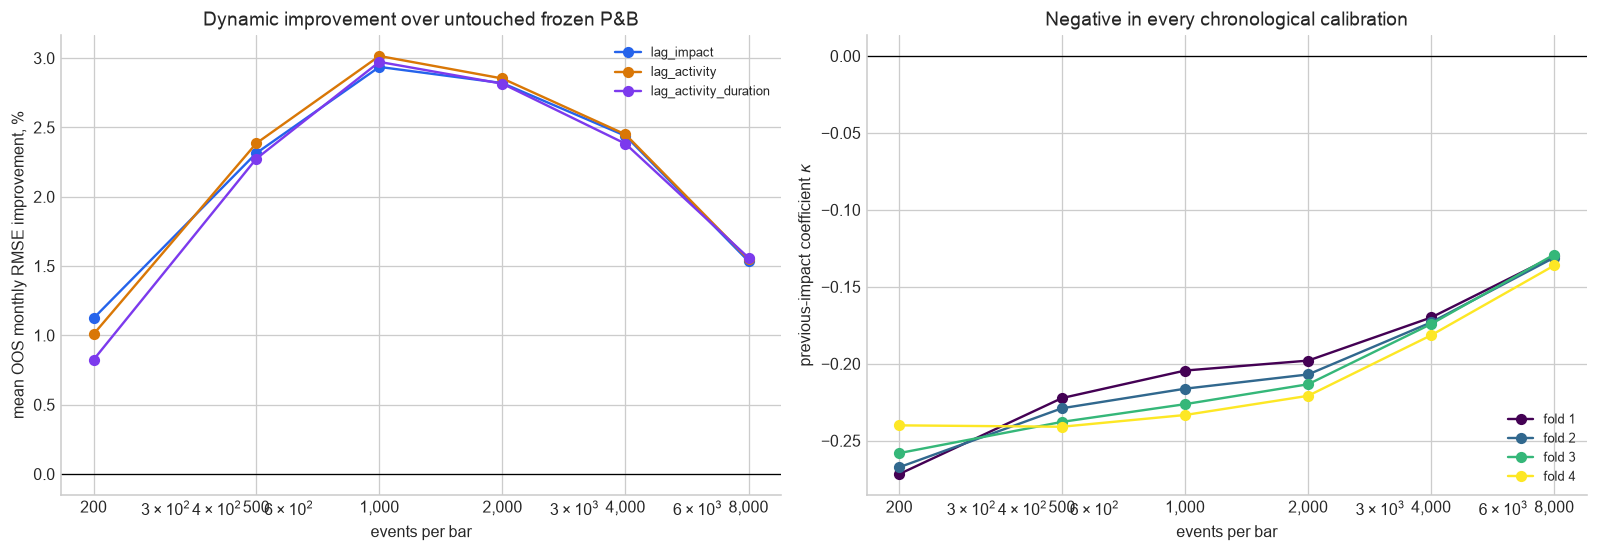

In [9]:
lag_base = lag_evaluation.filter(pl.col('model') == 'frozen_pb').select(
    'sample', 'fold', 'n_events',
    pl.col('mean_monthly_rmse').alias('frozen_pb_rmse')
)
lag_comparison = lag_evaluation.join(
    lag_base, on=['sample', 'fold', 'n_events']
).with_columns(
    (100 * (1 - pl.col('mean_monthly_rmse') / pl.col('frozen_pb_rmse')))
    .alias('rmse_improvement_pct')
)
lag_summary = (
    lag_comparison.filter(
        (pl.col('sample') == SAMPLE) &
        pl.col('model').is_in([
            'frozen_pb', 'lag_impact', 'lag_activity', 'lag_activity_duration'
        ])
    )
    .group_by('n_events', 'model')
    .agg(
        pl.col('mean_monthly_rmse').mean().alias('mean_oos_monthly_rmse'),
        pl.col('rmse_improvement_pct').mean().alias('mean_rmse_improvement_pct'),
        pl.col('rmse_improvement_pct').min().alias('worst_fold_improvement_pct'),
        pl.col('mean_monthly_residual_lag_impulse_correlation').mean()
        .alias('mean_residual_lag_correlation'),
    )
    .sort(['n_events', 'model'])
)
display(lag_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.9))
for model, colour in [
    ('lag_impact', '#2563eb'),
    ('lag_activity', '#d97706'),
    ('lag_activity_duration', '#7c3aed'),
]:
    part = lag_summary.filter(pl.col('model') == model).sort('n_events')
    axes[0].plot(
        part['n_events'], part['mean_rmse_improvement_pct'],
        'o-', color=colour, label=model
    )
axes[0].axhline(0, color='black', lw=.8)
axes[0].set_xscale('log')
axes[0].set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
axes[0].set_xlabel('events per bar')
axes[0].set_ylabel('mean OOS monthly RMSE improvement, %')
axes[0].set_title('Dynamic improvement over untouched frozen P&B')
axes[0].legend(fontsize=8)

coefficient_path = lag_coefficients.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('model') == 'lag_impact')
).sort(['fold', 'n_events'])
for fold_value, colour in zip(
    ['1', '2', '3', '4'], plt.cm.viridis(np.linspace(0, 1, 4))
):
    part = coefficient_path.filter(pl.col('fold') == fold_value).sort('n_events')
    axes[1].plot(
        part['n_events'], part['lag_impulse'], 'o-', color=colour,
        label=f'fold {fold_value}'
    )
axes[1].axhline(0, color='black', lw=.8)
axes[1].set_xscale('log')
axes[1].set_xticks(DISPLAY_SCALES, [f'{n:,}' for n in DISPLAY_SCALES])
axes[1].set_xlabel('events per bar')
axes[1].set_ylabel(r'previous-impact coefficient $\kappa$')
axes[1].set_title('Negative in every chronological calibration')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Visual form of the previous-bar relationship

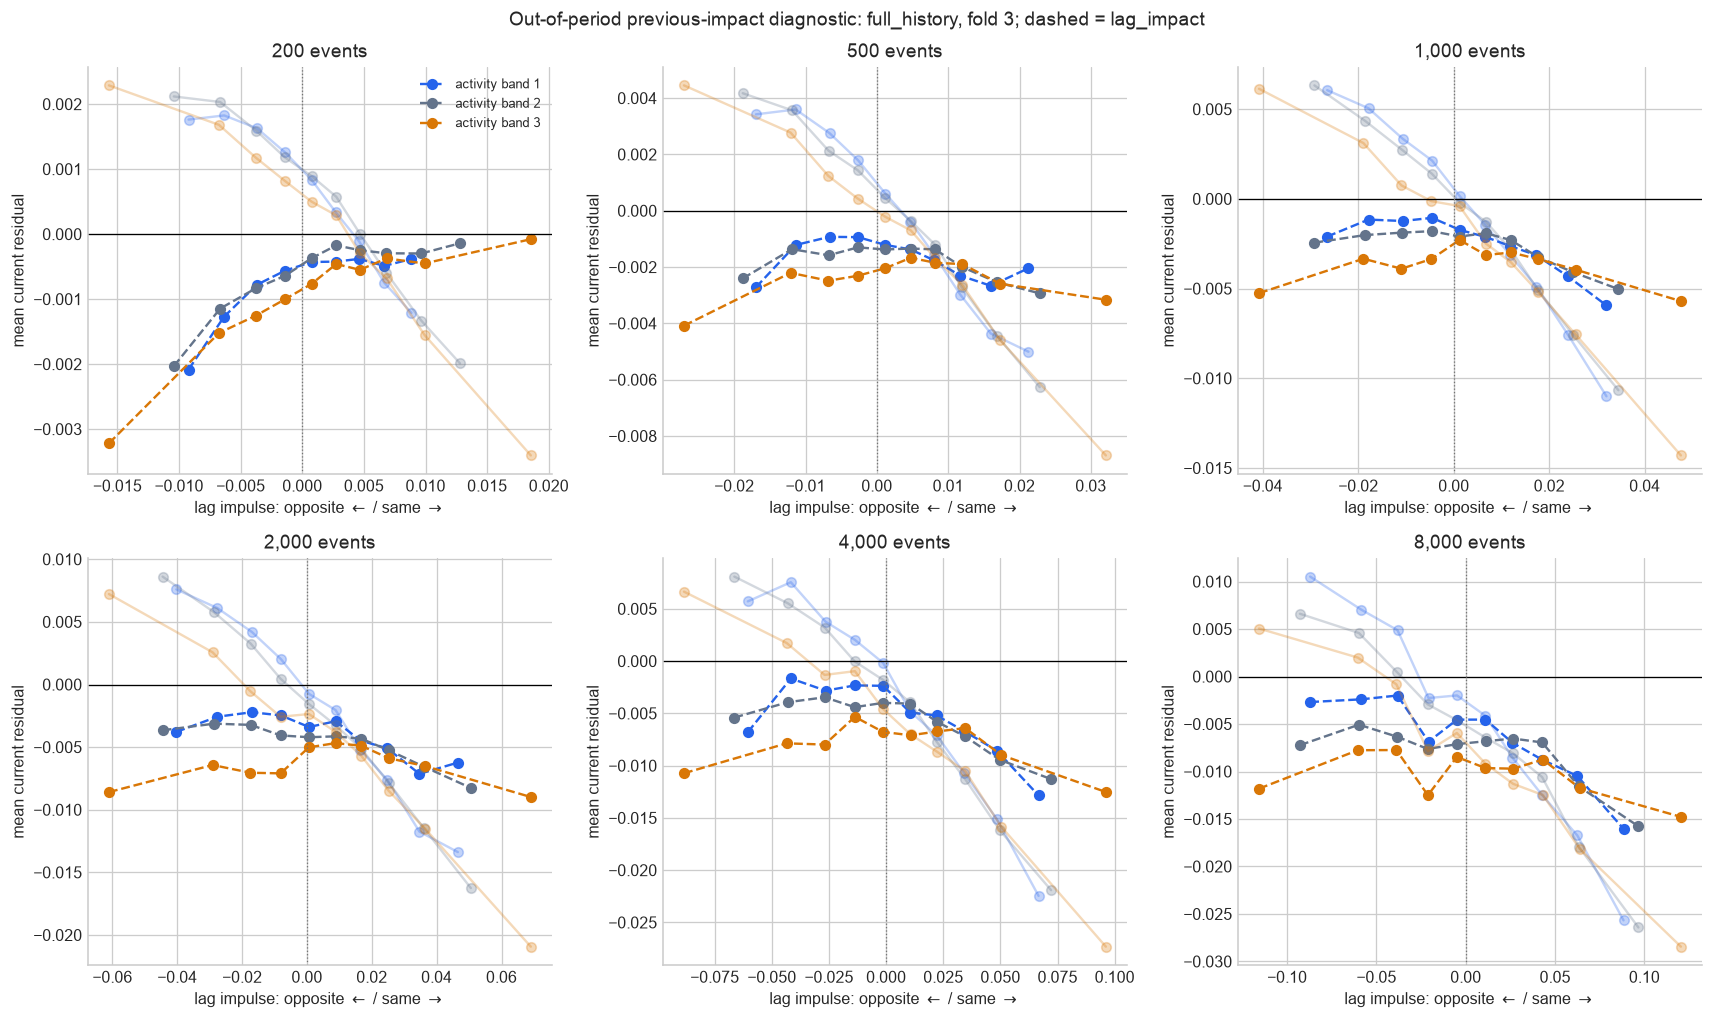

In [10]:
selected_lag_curves = lag_curves.filter(
    (pl.col('sample') == SAMPLE) &
    (pl.col('fold') == OOS_FOLD)
)
activity_colours = ['#2563eb', '#64748b', '#d97706']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False, sharey=False)
for ax, n_events in zip(axes.flat, DISPLAY_SCALES):
    scale_part = selected_lag_curves.filter(pl.col('n_events') == n_events)
    for band, colour in zip([1, 2, 3], activity_colours):
        part = scale_part.filter(
            pl.col('previous_activity_band') == band
        ).sort('mean_lag_impulse')
        ax.plot(
            part['mean_lag_impulse'], part['mean_residual_frozen_pb'],
            'o-', color=colour, alpha=.28
        )
        ax.plot(
            part['mean_lag_impulse'], part[f'mean_residual_{LAG_MODEL}'],
            'o--', color=colour, label=f'activity band {band}'
        )
    ax.axhline(0, color='black', lw=.8)
    ax.axvline(0, color='0.45', lw=.8, ls=':')
    ax.set_title(f'{n_events:,} events')
    ax.set_xlabel(r'lag impulse: opposite $\leftarrow$ / same $\rightarrow$')
    ax.set_ylabel('mean current residual')
axes.flat[0].legend(fontsize=8)
fig.suptitle(
    f'Out-of-period previous-impact diagnostic: {SAMPLE}, fold {OOS_FOLD}; '
    f'dashed = {LAG_MODEL}'
)
plt.tight_layout()
plt.show()

## Residuals as alpha factors

At the close of bar $t$, the side-aligned residual $\varepsilon_t$ is known. To
combine buy and sell bars in a predictor of an ordinary signed future return, it
must first be returned to price direction:

$$
x_t=s_t\varepsilon_t.
$$

A transparent multi-bar family is

$$
f_t^{(K)}=\sum_{k=0}^{K-1}w_kx_{t-k}.
$$

Combining residuals does **not** mechanically reduce their correlation with future
returns. It can improve forecast quality if the underlying response is distributed
across lags and the weights average idiosyncratic noise. If adjacent residuals are
strongly autocorrelated, however, extra lags mostly duplicate the same information.

The disciplined alpha comparison should therefore retain separate columns for:

- current signed residual $x_t$;
- residual histories with $K=2,3,5,10$;
- the observable decay factor $-s_tA_t$;
- ordinary past return, signed flow and pretrend controls.

Start with equal and exponentially decaying weights. Any fitted weights must be
regularised, calibrated only on the training window, and frozen for the following
validation/test period. The primary targets remain fixed 10- and 15-minute future
returns, with 30 seconds through 60 minutes retained as a term-structure diagnostic.

## Existing rolling residual evidence

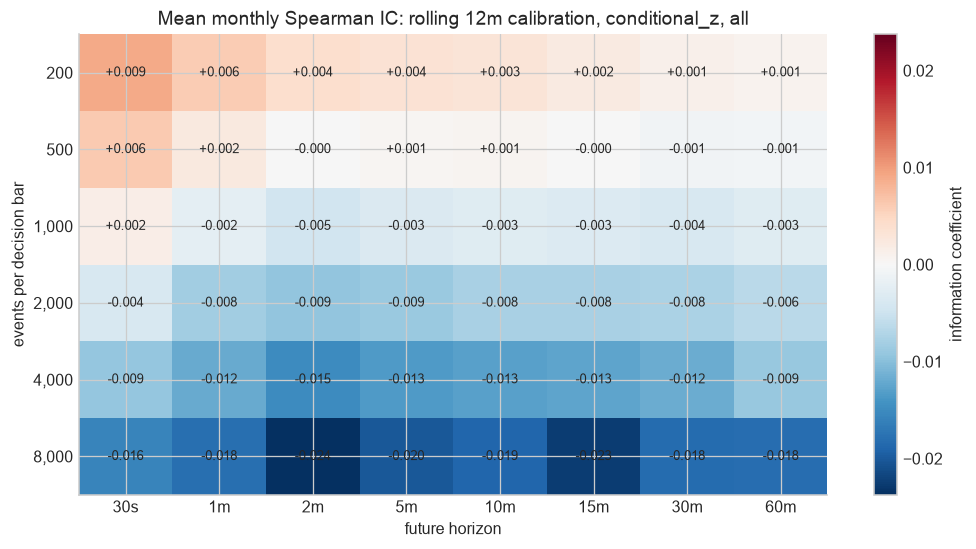

n_events,observations,pooled_pearson_ic,mean_monthly_spearman_ic,median_monthly_spearman_ic,monthly_spearman_t_stat,negative_spearman_month_fraction,median_elapsed_seconds,p90_elapsed_seconds
i64,i64,f64,f64,f64,f64,f64,f64,f64
200,8639295,0.001368,0.002174,0.002488,4.257769,0.245283,906.958,924.5837
500,3455720,0.001666,-0.000139,0.000035,-0.208332,0.490566,906.951,924.501
1000,1727860,0.00151,-0.003217,-0.002567,-3.901278,0.698113,906.964,924.46
2000,863888,0.000071,-0.007741,-0.007727,-6.169057,0.849057,906.938,924.336
4000,425635,-0.001802,-0.012585,-0.010451,-7.495732,0.886792,906.7935,923.9932
8000,171938,-0.006162,-0.022522,-0.019229,-7.033158,0.886792,906.234,921.5246


In [11]:
ic_view = residual_ic_summary.filter(
    (pl.col('training_window_months') == IC_TRAINING_WINDOW) &
    (pl.col('side') == IC_SIDE) &
    (pl.col('residual_variant') == RESIDUAL_VARIANT)
).sort(['n_events', 'horizon_seconds'])

event_sizes = sorted(ic_view['n_events'].unique().to_list())
horizons = sorted(ic_view['horizon_seconds'].unique().to_list())
matrix = np.full((len(event_sizes), len(horizons)), np.nan)
for row in ic_view.iter_rows(named=True):
    i = event_sizes.index(row['n_events'])
    j = horizons.index(row['horizon_seconds'])
    matrix[i, j] = row['mean_monthly_spearman_ic']

limit = np.nanmax(np.abs(matrix))
fig, ax = plt.subplots(figsize=(10.5, 5.2))
image = ax.imshow(matrix, cmap='RdBu_r', vmin=-limit, vmax=limit, aspect='auto')
ax.set_xticks(range(len(horizons)), [horizon_label(h) for h in horizons])
ax.set_yticks(range(len(event_sizes)), [f'{n:,}' for n in event_sizes])
ax.set_xlabel('future horizon')
ax.set_ylabel('events per decision bar')
ax.set_title(
    f'Mean monthly Spearman IC: rolling {IC_TRAINING_WINDOW}m calibration, '
    f'{RESIDUAL_VARIANT}, {IC_SIDE}'
)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f'{matrix[i,j]:+.3f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, label='information coefficient')
plt.show()

display(
    ic_view.filter(pl.col('horizon_seconds') == IC_HORIZON_SECONDS)
    .select(
        'n_events', 'observations', 'pooled_pearson_ic',
        'mean_monthly_spearman_ic', 'median_monthly_spearman_ic',
        'monthly_spearman_t_stat', 'negative_spearman_month_fraction',
        'median_elapsed_seconds', 'p90_elapsed_seconds'
    )
)

## Working interpretation

- `pb_activity` remains the canonical contemporaneous impact model.
- Its residual activity structure is documented rather than hidden by an unstable
  static extension.
- The negative previous-impact coefficient is treated as a separate dynamic
  reaction result and a candidate ex-ante decay factor.
- Static and dynamic residuals must both be preserved; the dynamic adjustment
  must not silently remove a potentially tradable effect.
- The next alpha step is a chronological residual-history screen using only
  information available at the signal timestamp, followed by turnover and cost
  modelling if a stable 10--15 minute relationship survives.